In [ ]:
import tensorflow as tf

I0000 00:00:1780837072.079651   40352 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780837072.980372   40352 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/tanish/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [157]:
print(tf.config.get_visible_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [158]:
mnist=tf.keras.datasets.mnist.load_data()
mnist

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [159]:
(X_train_full,y_train_full),(X_test,y_test)=mnist

In [160]:
print(X_train_full.shape)
y_train_full.shape

(60000, 28, 28)


(60000,)

In [161]:
X_test.shape

(10000, 28, 28)

In [162]:
X_train_full.dtype

dtype('uint8')

In [163]:
X_train,y_train=X_train_full[:-5000],y_train_full[:-5000]

In [164]:
X_valid,y_valid=X_train_full[-5000:],y_train_full[-5000:]

In [165]:
X_train,X_valid,X_test=X_train/255.,X_valid/255.,X_test/255.

In [166]:
X_test=X_test*255.

In [167]:
tf.random.set_seed(42)
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28,28]),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300,activation='relu'),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

In [168]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [169]:
#less efficient way
# model=tf.keras.Sequential()
# model.add(tf.keras.layers.Input())
# model.add(tf.keras.layers.Flatten())
# model.add(tf.keras.layers.Dense())
# model.add(tf.keras.layers.Dense())
# model.add(tf.keras.layers.Dense())

In [170]:
model.layers

[<Flatten name=flatten_1, built=True>,
 <Dense name=dense_43, built=True>,
 <Dense name=dense_44, built=True>,
 <Dense name=dense_45, built=True>]

In [ ]:
model.get_weights()

[array([[ 0.05474728,  0.04017063, -0.07052223, ..., -0.05373301,
         -0.04473822, -0.06258979],
        [ 0.00799178,  0.03176949, -0.0391749 , ..., -0.02084895,
          0.00047883,  0.07045075],
        [-0.01405276,  0.00939123,  0.04474636, ..., -0.01003736,
         -0.03217671, -0.0575841 ],
        ...,
        [ 0.01951231,  0.05431651, -0.00485847, ..., -0.04677437,
          0.01256787,  0.0257965 ],
        [-0.05296541,  0.0470245 , -0.01048709, ...,  0.05718952,
         -0.01536327, -0.06456582],
        [ 0.01188798,  0.00195201,  0.0502515 , ...,  0.07421361,
          0.05850184,  0.06141423]], shape=(784, 300), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [ ]:
history=model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))

Epoch 1/30


I0000 00:00:1780810234.666513    5241 service.cc:153] XLA service 0x7c77bc031080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780810234.669548    5241 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1780810234.916545    5241 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780810235.605395    5241 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1780810235.687342    5241 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1264__.13
I0000 00:00:1780810238.557174    5241 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints s

  12/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.2197 - loss: 2.1299    

I0000 00:00:1780810241.708522    5241 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1717/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8866 - loss: 0.3773

I0000 00:00:1780810255.344966    5245 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1264__.13


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - accuracy: 0.9349 - loss: 0.2174 - val_accuracy: 0.9704 - val_loss: 0.1018
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.9719 - loss: 0.0887 - val_accuracy: 0.9774 - val_loss: 0.0786
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9827 - loss: 0.0548 - val_accuracy: 0.9680 - val_loss: 0.1016
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9875 - loss: 0.0391 - val_accuracy: 0.9774 - val_loss: 0.0913
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9897 - loss: 0.0315 - val_accuracy: 0.9786 - val_loss: 0.0959
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9912 - loss: 0.0263 - val_accuracy: 0.9754 - val_loss: 0.1061
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9929 - loss: 0.0221 - val_accuracy: 0.9780 - val_loss: 0.0936
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9933 - loss: 0.0208 - va

In [ ]:
history.history

{'accuracy': [0.9348909258842468,
  0.9719454646110535,
  0.9826545715332031,
  0.9874545335769653,
  0.9897090792655945,
  0.9911817908287048,
  0.9929454326629639,
  0.993254542350769,
  0.9942545294761658,
  0.9951454401016235,
  0.994454562664032,
  0.9960181713104248,
  0.9955090880393982,
  0.9958363771438599,
  0.996218204498291,
  0.9957818388938904,
  0.99632728099823,
  0.997036337852478,
  0.9972000122070312,
  0.9967454671859741,
  0.9975818395614624,
  0.9972727298736572,
  0.9975273013114929,
  0.9966182112693787,
  0.9979636073112488,
  0.9973454475402832,
  0.9971818327903748,
  0.996963620185852,
  0.9982908964157104,
  0.9976909160614014],
 'loss': [0.21737274527549744,
  0.08872580528259277,
  0.05481017753481865,
  0.03907589241862297,
  0.0314607098698616,
  0.026306798681616783,
  0.022064341232180595,
  0.020765947178006172,
  0.01778421923518181,
  0.014619706198573112,
  0.0172545425593853,
  0.012541144154965878,
  0.014061740599572659,
  0.0124552883207798,
 

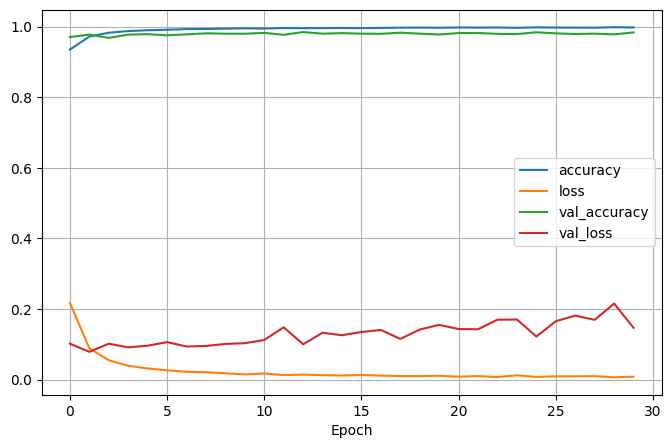

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
pd.DataFrame(history.history).plot(
    figsize=(8,5), grid=True,
    xlabel="Epoch"
)
plt.show()

In [ ]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.01)

In [ ]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9822 - loss: 0.1390


[0.138990581035614, 0.982200026512146]

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_valid.shape)
print(y_valid.shape)
print(X_test.shape)
print(y_test.shape)

(55000, 28, 28)
(55000,)
(5000, 28, 28)
(5000,)
(10000, 28, 28)
(10000,)


In [ ]:
X_new=X_test[4:6]
y_proba=model.predict(X_new)
y_proba.round(5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
y_pred=y_proba.argmax(axis=-1)
y_pred

array([4, 1])

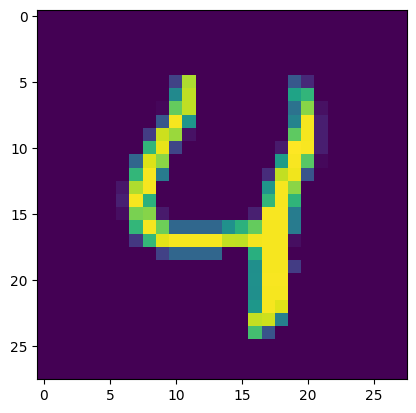

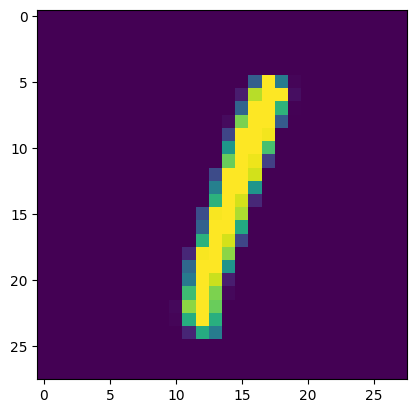

In [ ]:
plt.imshow(X_new[0])
plt.show()
plt.imshow(X_new[1])
